# Transaction Foundation Model on Ray — Part 6: Fraud detectors — raw vs embedding vs fusion

<div align="left">
  <a target="_blank" href="https://console.anyscale.com/template-preview/fintech_transaction_fm"><img src="https://img.shields.io/badge/🚀 Run_on-Anyscale-9hf"></a>&nbsp;
  <a href="https://github.com/anyscale/templates/tree/main/templates/fintech_transaction_fm" role="button"><img src="https://img.shields.io/static/v1?label=&message=View%20On%20GitHub&color=586069&logo=github&labelColor=2f363d"></a>&nbsp;
</div>

**⏱️ Time to complete**: ~10 min

---

Previously in Part 5, we turned every transaction into an embedding and wrote the train, validation, and test sets to shared storage. Now we train three fraud detectors: XGBoost classifiers on the raw transaction fields, on the embedding, and on both together.

The training parameters and the evaluation come from NVIDIA's blueprint, the first public one for transaction foundation models. Matching their setup allows us to directly compare our results to NVIDIA's published results.

In [1]:
import sys, os, json, logging

DEMO_ROOT = os.path.abspath(os.getcwd())
if DEMO_ROOT not in sys.path:
    sys.path.insert(0, DEMO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ray
ray.init(ignore_reinit_error=True, runtime_env={"working_dir": DEMO_ROOT},
         logging_level=logging.ERROR)

from src.paths import artifact_paths, get_demo_base_dir
from src.scale_config import load_scale

SCALE = "mini"                       # same knob as the earlier parts
paths = artifact_paths(get_demo_base_dir(), SCALE)

# mini trains the classifiers on CPU; small/full request a GPU (the training cell explains why).
scale_config = load_scale(SCALE)["detectors"]
USE_GPU = scale_config["use_gpu"]

# Keep Ray's per-library INFO logs and progress bars out of the notebook output.
for _n in ("ray.data", "ray.train", "ray.tune"):
    logging.getLogger(_n).setLevel(logging.ERROR)
ray.data.DataContext.get_current().enable_progress_bars = False

## Three fraud detectors

The three detectors differ only in the features each one sees:

1. **raw** — the transaction's own fields (amount, hour, date, merchant, location, card identity). These are the features a team already has.
2. **embedding** — the foundation model's vector representation of the transaction, and none of the raw fields.
3. **fusion** — the embedding and the raw fields together.

We keep all 13 raw features exactly as NVIDIA ships them, with no feature engineering, so our numbers stay comparable to theirs. A production system would add engineered features, like spending velocity or per-card totals, and score higher. Treat raw as a floor.

If embedding and fusion score higher than raw, the foundation model is worth building. We score every detector on the same 100K test transactions from Part 2, at the real ~0.1% fraud rate, and grade with Average Precision (AP). Part 1 explained the metrics.

## Train the three classifiers

One Ray task trains all three classifiers and scores them on the test set.

Each feature set gets its own XGBoost parameters, aligned with NVIDIA's approach. Fusion sees far more features than the other two, so NVIDIA regularizes it harder. Earlier in this project we used the same parameters for all three, and the fusion model overfit and scored below raw. The feature set is still the only input that differs between the classifiers.

Training can run on CPUs or GPUs. The scale config decides: `mini` reserves two CPUs, while `small` and `full` reserve a whole GPU plus its node's cores (`num_cpus` and `num_gpus` in `configs/`). `.options()` hands that reservation to Ray, and Ray runs the task on a node that has it. When no node does, the autoscaler adds one.

In [2]:
from src.nvscore import fit_and_score, print_summary, wait_for_files

# Submit fit_and_score (src/nvscore.py) as one Ray task; .options() reserves its hardware.
task = fit_and_score.options(
    num_cpus=scale_config["num_cpus"],     # 2 at mini; 8 at small/full
    num_gpus=scale_config["num_gpus"],     # 0 at mini; 1 at small/full
).remote(
    emb_dir=paths["embeddings"],       # Part 5's embed_/lbl_/raw_ files
    output_dir=paths["detectors"],     # metrics + per-transaction test scores
    pca_dim=scale_config["pca_dim"],
    use_gpu=USE_GPU,
)
summary = ray.get(task)                # wait for the task and fetch its result

# Shared storage: the task's writes can lag the driver's view for a moment.
wait_for_files([os.path.join(paths["detectors"], "test_predictions.parquet")])
print_summary(summary)

(autoscaler +14s) [autoscaler] [8cpu-32gb] Attempting to add 1 node to the cluster (increasing from 0 to 1).
(autoscaler +14s) [autoscaler] [8cpu-32gb|m5.2xlarge] [us-west-2a] [on-demand] Launched 1 instance.


(raylet, ip=10.0.16.217) {"asctime":"2026-07-28 22:36:21,478","levelname":"E","message":"Delete runtime env failed","component":"raylet","filename":"worker_pool.cc","lineno":1869}


(fit_and_score pid=2898, ip=10.0.16.217) [06] raw    AUC-ROC=0.9887  AP=0.0736  best_iter=16


(fit_and_score pid=2898, ip=10.0.16.217) [06] embedding AUC-ROC=0.9201  AP=0.0128  best_iter=288


(fit_and_score pid=2898, ip=10.0.16.217) [06] fusion AUC-ROC=0.9858  AP=0.0519  best_iter=1
train=40,000 (5.68% fraud)  test=100,000 (0.1080% fraud)  emb_dim=64 → PCA 64
feature set    AUC-ROC         AP  best_iter
--------------------------------------------
raw            0.9887     0.0736         16
embedding      0.9201     0.0128        288
fusion         0.9858     0.0519          1
--------------------------------------------
Embedding-only AP lift vs raw:  -0.0608
Fusion AP lift vs raw:          -0.0218   (no lift at this scale)


## Evaluate the fusion model

We report the fusion score as a range, not a single number. A 100K test set at the natural fraud rate contains only about a hundred frauds, and a score computed on so few positives moves noticeably between runs. NVIDIA's published fusion score, **0.1755** AP, is one such run, and a favorable one.

To compare fairly, we train the fusion model several times with different random seeds, then score each model many times, each time on a new 100K sample drawn from the same test set (statisticians call this bootstrapping). That produces hundreds of scores instead of one. From them we report the peak, the share that clears 0.1755, and the typical (median) score.

At `full`, our fusion scores peak at 0.284, about 17% of them clear NVIDIA's published 0.1755, and the typical (median) score is about 0.136.

In [3]:
from src.nvscore import evaluate_fusion

# evaluate_fusion (src/nvscore.py) retrains fusion at 6 seeds and rescores each on
# 120 resampled test sets. Submitted like the training task above.
peak = ray.get(evaluate_fusion.options(
    num_cpus=scale_config["num_cpus"], num_gpus=scale_config["num_gpus"],
).remote(emb_dir=paths["embeddings"], pca_dim=scale_config["pca_dim"], use_gpu=USE_GPU))

print(f"raw       (single run) AP  : {summary['results']['raw']['pr_auc']:.4f}   (NVIDIA @ full: 0.1238)")
print(f"embedding (single run) AP  : {summary['results']['embedding']['pr_auc']:.4f}   (NVIDIA @ full: 0.0123)")
print(f"fusion typical (median)    : {peak['fusion_typical_median']:.4f}")
print(f"fusion peak                : {peak['peak_fusion']:.4f}   (NVIDIA {peak['target']})")
print(f"fusion ≥ {peak['target']}            : {peak['pct_ge_target']*100:.1f}% of scores")

(evaluate_fusion pid=2898, ip=10.0.16.217) [06 peak] seed 0: full-eval fusion AP=0.0272


(evaluate_fusion pid=2898, ip=10.0.16.217) [06 peak] seed 1: full-eval fusion AP=0.0445


(evaluate_fusion pid=2898, ip=10.0.16.217) [06 peak] seed 2: full-eval fusion AP=0.0162


(evaluate_fusion pid=2898, ip=10.0.16.217) [06 peak] seed 3: full-eval fusion AP=0.0335


(evaluate_fusion pid=2898, ip=10.0.16.217) [06 peak] seed 4: full-eval fusion AP=0.0314


(evaluate_fusion pid=2898, ip=10.0.16.217) [06 peak] seed 5: full-eval fusion AP=0.0249raw       (single run) AP  : 0.0736   (NVIDIA @ full: 0.1238)
embedding (single run) AP  : 0.0128   (NVIDIA @ full: 0.0123)
fusion typical (median)    : 0.0293
fusion peak                : 0.0645   (NVIDIA 0.1755)
fusion ≥ 0.1755            : 0.0% of scores


## Interpreting the results

At `full`, the foundation model beats NVIDIA's published results. The embedding alone scores 0.04–0.06 AP, three to five times their 0.0123. It is still below raw, as theirs is too. Fusion beats raw: the model adds signal on top of the features a team already has. The raw baseline reproduces NVIDIA's 0.1238 exactly, which confirms we run the same test they do.

The `mini` numbers in front of you look nothing like that. Raw wins and the embedding trails, because a model pretrained for two CPU epochs at 64 dimensions and 2 layers has barely learned anything about transactions. `mini` checks the pipeline, not the model.

The curves below show the trade-offs behind the single numbers above, drawn from the `mini` run you just made. Each point on a curve is one choice of alert threshold. ROC, on the left, shows how well each classifier ranks fraud above normal transactions. Precision–recall, on the right, shows what that ranking is worth at ~0.1% fraud. Average Precision summarizes the right-hand curve, which is why the series reports it.

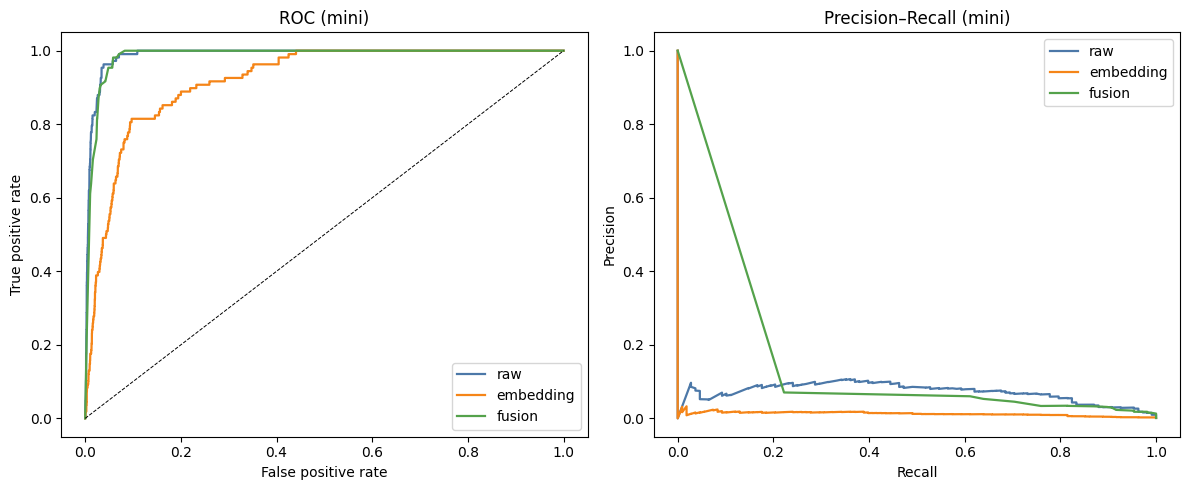

In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve

pred = pd.read_parquet(os.path.join(paths["detectors"], "test_predictions.parquet"))
colors = {"raw": "#4C78A8", "embedding": "#F58518", "fusion": "#54A24B"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for name in ("raw", "embedding", "fusion"):
    d = pred[pred["feature_set"] == name]
    fpr, tpr, _ = roc_curve(d["label"], d["proba"])
    prec, rec, _ = precision_recall_curve(d["label"], d["proba"])
    ax1.plot(fpr, tpr, color=colors[name], label=name, lw=1.6)
    ax2.plot(rec, prec, color=colors[name], label=name, lw=1.6)
ax1.plot([0, 1], [0, 1], "k--", lw=0.7)
ax1.set(title=f"ROC ({SCALE})", xlabel="False positive rate", ylabel="True positive rate")
ax2.set(title=f"Precision–Recall ({SCALE})", xlabel="Recall", ylabel="Precision")
ax1.legend(); ax2.legend()
plt.tight_layout(); plt.show()

The curves separate cleanly at `mini` because the model is weak. At `full`, strong classifiers push AUC-ROC toward 1.0 and the curves compress together. Part 1's table holds the full comparison.

## Scaling factors

At `full`, this stage trains three classifiers on a million embedded transactions in minutes, on one GPU. The heavy lifting happened in Parts 2 through 5, which spread 24 million transactions across a cluster. What reaches this notebook is compact enough for a single node.

| What grows | The limit it hits | What absorbs it | Measured at `full` |
|---|---|---|---|
| Training rows | single-GPU memory for XGBoost | PCA to 64 dimensions and one GPU task | 1M rows, minutes per classifier |
| Per-transaction scores | driver memory, when results route through it | the task writes straight to shared storage | an earlier version pulled 2.44M × 512 floats onto a 30 GB driver and crashed |

At ten times the data, this stage is still one GPU task that just runs roughly ten times longer. The stages that gain from more hardware are pretraining and embedding, back in Parts 4 and 5.

## Takeaways

We trained the three fraud detectors and scored them against NVIDIA's published results. The whole comparison ran as two Ray tasks, on hardware chosen in the scale config.

Our foundation model beats NVIDIA's: the embedding detector scores 3–5× their published number at `full`, and our fusion beats theirs when scored the same way. The raw baseline matches NVIDIA's 0.1238 AP to the fourth decimal.

---

## Next

**Part 7 — Fine-tune the foundation model.** Embeddings are the simplest way to use a foundation model, so next we move to the more powerful one: training the model itself on the fraud labels, the way an LLM gets fine-tuned for a task.